In [5]:
import os
import shutil

def organize_by_filename(root_dir):
    """
    파일명을 기준으로 '_<클래스>' 뒤 숫자를 클래스 폴더로 이동
    """
    for filename in os.listdir(root_dir):
        file_path = os.path.join(root_dir, filename)

        # 파일인지 확인
        if os.path.isfile(file_path):
            # 파일명에서 클래스 정보 추출
            parts = filename.split("_")
            if len(parts) > 1:
                #class_name = parts[-1].split(".")[0]  # 확장자 제거
                class_name = parts[0]
                class_folder = os.path.join(root_dir, class_name)

                # 클래스 폴더가 없으면 생성
                os.makedirs(class_folder, exist_ok=True)

                # 파일 이동
                shutil.move(file_path, os.path.join(class_folder, filename))

# 정리할 데이터 경로 지정
#train_path = "data/yolovnumber/train"
#valid_path = "data/yolovnumber/valid"
#test_path = "data/yolovnumber/test"
test_path = "mnist_images/test"
#organize_by_filename(train_path)
#organize_by_filename(valid_path)
organize_by_filename(test_path)

print("파일 정리가 완료되었습니다.")


파일 정리가 완료되었습니다.


In [ ]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# Define transformations for the images
transform = transforms.Compose([
    #transforms.Grayscale(num_output_channels=1),
    transforms.Grayscale(),        # Ensure images are grayscale
    transforms.Resize((28, 28)),   # Resize to 28x28
    transforms.ToTensor(),         # Convert to tensor
])
# Load the train dataset using ImageFolder
dataset_path = "data/test1/train"
train_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# Load the valid dataset using ImageFolder
dataset_path = "data/test1/valid"
valid_dataset = datasets.ImageFolder(root=dataset_path, transform=transform)
valid_loader = DataLoader(valid_dataset, batch_size=32, shuffle=True)

# Print class names
print(f"Classes: {train_dataset.classes}")


c:\Users\user\anaconda3\envs\LP\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9', '영']


#개선

In [2]:
len(train_dataset.classes)

11

In [ ]:
import torch.nn as nn
import torch.nn.functional as F

# class FCModel(nn.Module):
#     def __init__(self, num_classes):
#         super(FCModel, self).__init__()
#         self.fc1 = nn.Linear(28 * 28, 128)
#         self.fc2 = nn.Linear(128, 64)
#         self.fc3 = nn.Linear(64, num_classes)

#     def forward(self, x):
#         x = x.view(-1, 28 * 28)  # Flatten the image
#         x = F.relu(self.fc1(x))
#         x = F.relu(self.fc2(x))
#         x = self.fc3(x)
#         return x

# # Initialize the model
# num_classes = len(train_dataset.classes)
# model = FCModel(num_classes)

class CNNModel(nn.Module):
    def __init__(self, num_classes):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.dropout = nn.Dropout(0.5)
        self.fc2 = nn.Linear(128, 64)
        self.dropout2 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = F.relu(self.fc2(x))
        x = self.dropout2(x)
        x = self.fc3(x)
        return x  

# 모델 초기화
num_classes = len(train_dataset.classes)
model = CNNModel(num_classes)  # CNN 모델 사용






In [3]:
import torch
import torch.optim as optim

# Define the loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training loop
num_epochs = 50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

for epoch in range(num_epochs):

    # Training phase
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:

        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    avg_train_loss = running_loss / len(train_loader)

    # Validation phase
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in valid_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    avg_val_loss = val_loss / len(valid_loader)
    val_accuracy = 100 * correct / total

    # Epoch finished
    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f} | Val Accuracy: {val_accuracy:.2f}%\n")

print("Training complete!")


Epoch [1/50]
Train Loss: 0.8540 | Val Loss: 0.0572 | Val Accuracy: 98.69%

Epoch [2/50]
Train Loss: 0.2517 | Val Loss: 0.0329 | Val Accuracy: 99.16%

Epoch [3/50]
Train Loss: 0.1630 | Val Loss: 0.0200 | Val Accuracy: 99.37%

Epoch [4/50]
Train Loss: 0.1292 | Val Loss: 0.0232 | Val Accuracy: 99.53%

Epoch [5/50]
Train Loss: 0.1172 | Val Loss: 0.0222 | Val Accuracy: 99.37%

Epoch [6/50]
Train Loss: 0.0944 | Val Loss: 0.0180 | Val Accuracy: 99.42%

Epoch [7/50]
Train Loss: 0.0845 | Val Loss: 0.0215 | Val Accuracy: 99.37%

Epoch [8/50]
Train Loss: 0.0836 | Val Loss: 0.0144 | Val Accuracy: 99.58%

Epoch [9/50]
Train Loss: 0.0765 | Val Loss: 0.0139 | Val Accuracy: 99.53%

Epoch [10/50]
Train Loss: 0.0696 | Val Loss: 0.0151 | Val Accuracy: 99.63%

Epoch [11/50]
Train Loss: 0.0637 | Val Loss: 0.0240 | Val Accuracy: 99.58%

Epoch [12/50]
Train Loss: 0.0630 | Val Loss: 0.0177 | Val Accuracy: 99.58%

Epoch [13/50]
Train Loss: 0.0595 | Val Loss: 0.0230 | Val Accuracy: 99.48%

Epoch [14/50]
Train L

In [5]:
import numpy as np
from sklearn.metrics import confusion_matrix, classification_report, f1_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load test dataset using ImageFolder
test_dataset_path = "data/yolovnumber/alltest"  # Update with your test dataset path
test_dataset = datasets.ImageFolder(root=test_dataset_path, transform=transform)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Evaluate the model and store predictions
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Compute the confusion matrix
cm = confusion_matrix(all_labels, all_preds)
classes = test_dataset.classes

# Print classification report
print("Classification Report:")
print(classification_report(all_labels, all_preds, target_names=classes))

# Compute and print F1-score
f1 = f1_score(all_labels, all_preds, average='weighted')
print(f"Weighted F1-Score: {f1:.4f}")

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=classes, yticklabels=classes)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()


Classification Report:


ValueError: Number of classes, 11, does not match size of target_names, 10. Try specifying the labels parameter

In [4]:
# download the model
torch.save(model.state_dict(), "persian_digit_classifier_resize(112,224)_0214_epo50.pt")

In [13]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.transforms as transforms
import cv2
import numpy as np


# Define the MNIST-like Fully Connected Model
class FCModel(nn.Module):
    def __init__(self, num_classes):
        super(FCModel, self).__init__()
        self.fc1 = nn.Linear(28 * 28, 128)
        self.fc2 = nn.Linear(128, 64)
        self.fc3 = nn.Linear(64, num_classes)

    def forward(self, x):
        x = x.view(-1, 28 * 28)  # Flatten the image
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


# ImageClassifier class encapsulating model loading, preprocessing, and prediction
class ImageClassifier:
    def __init__(self, weights_path, class_names):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        self.class_names = class_names
        self.model = self._load_model(weights_path)
        self.model.to(self.device)
        self.model.eval()
        self.transform = self._get_transform()

    def _load_model(self, weights_path):
        """Load the trained model with weights."""
        num_classes = len(self.class_names)
        model = FCModel(num_classes)
        model.load_state_dict(torch.load(weights_path, map_location=self.device))
        print("Model loaded successfully.")
        return model

    def _get_transform(self):
        """Define the preprocessing transformations."""
        return transforms.Compose([
            transforms.Grayscale(),           # Convert to grayscale
            transforms.Resize((28, 28)),      # Resize to 28x28
            transforms.ToTensor(),            # Convert to tensor
        ])

    def preprocess_image(self, image):
        """Preprocess the input OpenCV image."""
        # Convert BGR to RGB (OpenCV loads images in BGR by default)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        #추가함
        image_pil = Image.fromarray(image_rgb)
        image_tensor = self.transform(image_pil).unsqueeze(0)  # Add batch dimension
        print("Aa",image_tensor.shape)
        return image_tensor.to(self.device)

    def predict(self, image):
        """Predict the class of the given image."""
        image_tensor = self.preprocess_image(image)
        with torch.no_grad():
            outputs = self.model(image_tensor)
            _, predicted = torch.max(outputs, 1)
            predicted_class = self.class_names[predicted.item()]
        return predicted_class


# Example usage
if __name__ == "__main__":
    weights_path = 'persian_digit_classifier.pt'
    class_names = ['0', '1', '2','3','4','5','6','7','8','9']

    classifier = ImageClassifier(weights_path, class_names)

    # Read an image using OpenCV
    image_path = 'path/to/your/image.jpg'  # Update this with the path to your test image
    image = cv2.imread(image_path)

    if image is None:
        print(f"Error: Unable to load image at {image_path}")
    else:
        # Predict the class
        predicted_class = classifier.predict(image)
        print(f"Predicted Class: {predicted_class}")


Model loaded successfully.
Error: Unable to load image at path/to/your/image.jpg


(284, 152, 3)
Aa torch.Size([1, 1, 28, 28])
Predicted Class: 0


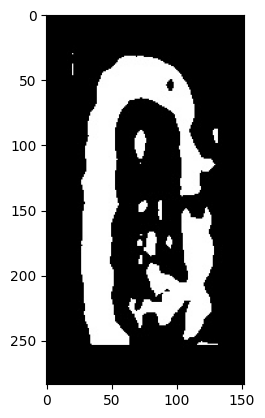

In [ ]:
from PIL import Image
image_path = 'yolovnumber121212/(158).jpg'  # Update this with the path to your test image
image = cv2.imread(image_path)
predicted_class = classifier.predict(image)
print(f"Predicted Class: {predicted_class}")

plt.imshow(image)
plt.show()